# Task multi-label training

Trains a single multi-label model on the 4-class task dataset (3 target
species + `non_target`). Outputs are independent sigmoids — a clip can
fire more than one class at a time, which matches reality (multiple birds
can be present in the same window). Decisions are per-class above
`THRESHOLD` rather than argmax.

Metrics: per-class precision/recall/F1/F2 at threshold, macro averages,
subset (exact-match) accuracy, one-vs-rest ROC/AUC, per-class prediction
rates by true class.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import os

import pyrootutils

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

ROOT = pyrootutils.setup_root(
    search_from=Path.cwd(),
    indicator="pyproject.toml",
    pythonpath=True,
    dotenv=True,
)

## Parameters

In [3]:
# COLLECTION is the on-disk dataset folder name produced by
# dataset_build.ipynb — i.e. task_slug(TARGET_SPECIES, LAT, LON, RADIUS_KM).
COLLECTION = "task_s3_49_2_r50"
BUILD_MODEL = "sincnet"  # one of: mel_cnn, cnn1d, sincnet, leaf
EPOCHS = 100
PATIENCE = 15
BATCH_SIZE = 16
SEED = 42
THRESHOLD = 0.5  # per-class decision threshold for the multi-label metrics
NON_TARGET_NAME = "non_target"

# Results: one folder per (species, area) experiment, with one JSON per run.
RUN_NAME = BUILD_MODEL
RESULTS_FILE = ROOT / "results" / COLLECTION / f"{RUN_NAME}.json"
MODEL_PATH = ROOT / "models" / COLLECTION / f"{BUILD_MODEL}.keras"

## Load dataset catalog

Uses the same per-class cached waveform catalog that `scaling.py` builds. The
first run populates `.cache/<collection>/waveform_<hash>/` for each split; later
runs hit the cache directly.

In [ ]:
import logging
import warnings

import numpy as np
import tensorflow as tf

tf.get_logger().setLevel("ERROR")
logging.getLogger("absl").setLevel("ERROR")
warnings.filterwarnings("ignore", message=".*AudioResample.*")

from building.scaling import (
    build_dataset_from_catalog,
    collect_predictions,
    compute_metrics,
    load_dataset_catalog,
    model_factory,
)
from building.models import input_repr_for

catalog = load_dataset_catalog(COLLECTION)

non_target_idx = catalog.class_names.index(NON_TARGET_NAME)
target_idxs = [i for i, n in enumerate(catalog.class_names) if n != NON_TARGET_NAME]
final_labels = [catalog.class_names[i] for i in target_idxs] + [NON_TARGET_NAME]
print(f"target_idxs={target_idxs}  non_target_idx={non_target_idx}")
print(f"final label order: {final_labels}")

In [ ]:
import pandas as pd

counts = pd.DataFrame(
    [(e.name, e.train.count, e.val.count, e.test.count) for e in catalog.entries],
    columns=["class", "train", "val", "test"],
).set_index("class")
counts["total"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum(axis=0)

(
    counts.style
    .background_gradient(cmap="Blues", subset=(counts.index[:-1], ["train", "val", "test"]))
    .format("{:,}")
    .set_caption(f"Sample counts per class × split  ({COLLECTION})")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "110%"), ("padding", "6px 0")]},
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "4px 10px")]},
    ])
)

,train,val,test,total
class,,,,
Emberiza_calandra,"5,600","1,200","1,200","8,000"
Hippolais_polyglotta,"5,431","1,163","1,165","7,759"
Regulus_ignicapilla,"5,600","1,200","1,200","8,000"
non_target,"17,912","3,835","3,847","25,594"
TOTAL,"34,543","7,398","7,412","49,353"


## Build train/val/test pipelines

`build_dataset_from_catalog` shuffles each class independently, repeats, and
mixes via `sample_from_datasets` so every training batch is class-balanced
regardless of class size. Validation/test use the natural distribution.

In [ ]:
input_repr = input_repr_for(BUILD_MODEL)
rng = np.random.default_rng(SEED)

train_ds, meta = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="train", input_repr=input_repr, augment=True,
)
val_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="val", input_repr=input_repr, augment=False,
)
test_ds, _ = build_dataset_from_catalog(
    catalog, target_idxs, non_target_idx, BATCH_SIZE, rng,
    split="test", input_repr=input_repr, augment=False,
)
print(f"n_classes={meta.n_classes}  epoch_samples={meta.epoch_samples}")
print("class_weights:")
for lbl, w in meta.class_weights.items():
    print(f"  {final_labels[lbl]:<24s} {w:.3f}")

n_classes=4  epoch_samples=34543
class_weights:
  Emberiza_calandra        1.196
  Hippolais_polyglotta     1.233
  Regulus_ignicapilla      1.196
  non_target               0.374


## Build model and train

In [ ]:
tf.keras.backend.clear_session()
model = model_factory(BUILD_MODEL)(meta.n_classes)
model.summary()

Model: "cnn2d_mel_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mel_spectrogram (InputLayer)    │ (None, 184, 80, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 182, 78, 8)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 91, 78, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 91, 78, 8)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 89, 76, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 44, 38, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 44, 38, 8)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ chirp_patterns (Conv2D)         │ (None, 30, 20, 8)      │        18,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 8)              │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,948 (74.02 KB)

 Trainable params: 18,948 (74.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
        ),
    ],
)
print(f"Stopped after {len(history.history['loss'])} epochs")

Epoch 1/100


I0000 00:00:1779185141.243405 3233214 service.cc:145] XLA service 0x781e64004550 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779185141.243448 3233214 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1779185145.242039 3233214 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2159/2159 - 73s - 34ms/step - accuracy: 0.5805 - loss: 0.3050 - precision: 0.6830 - recall: 0.4806 - val_accuracy: 0.7511 - val_loss: 0.1751 - val_precision: 0.8450 - val_recall: 0.6427
Epoch 2/100
2159/2159 - 67s - 31ms/step - accuracy: 0.6823 - loss: 0.2306 - precision: 0.8101 - recall: 0.5675 - val_accuracy: 0.8141 - val_loss: 0.1315 - val_precision: 0.8885 - val_recall: 0.7282
Epoch 3/100
2159/2159 - 58s - 27ms/step - accuracy: 0.7242 - loss: 0.2074 - precision: 0.8492 - recall: 0.6163 - val_accuracy: 0.8227 - val_loss: 0.1217 - val_precision: 0.8757 - val_recall: 0.7713
Epoch 4/100
2159/2159 - 59s - 27ms/step - accuracy: 0.7341 - loss: 0.2014 - precision: 0.8580 - recall: 0.6239 - val_accuracy: 0.8256 - val_loss: 0.1134 - val_precision: 0.8838 - val_recall: 0.7590
Epoch 5/100
2159/2159 - 63s - 29ms/step - accuracy: 0.7437 - loss: 0.1942 - precision: 0.8679 - recall: 0.6363 - val_accuracy: 0.8333 - val_loss: 0.1122 - val_precision: 0.9015 - val_recall: 0.7736
Epoch 6/100
2159/2159 

## Training curves

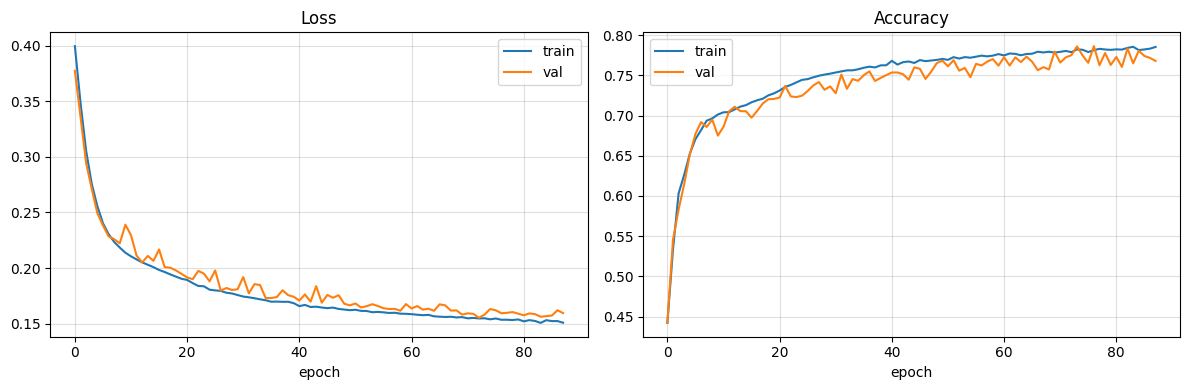

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.4)

acc_key = next(
    (k for k in ("accuracy", "categorical_accuracy") if k in history.history),
    None,
)
if acc_key is not None:
    axes[1].plot(history.history[acc_key], label="train")
    axes[1].plot(history.history[f"val_{acc_key}"], label="val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Evaluate on test set

`compute_metrics` already does the multi-label macro at `THRESHOLD`
(per-class precision/recall, then averaged). Outputs are sigmoid
probabilities, so each class is its own independent binary decision.

In [ ]:
test_loss = float(model.evaluate(test_ds, verbose=0)[0])
y_true, y_pred = collect_predictions(model, test_ds)
print(f"y_true {y_true.shape}  y_pred {y_pred.shape}  test_loss={test_loss:.4f}")

m = compute_metrics(y_true, y_pred, THRESHOLD, test_loss)
print()
print(f"Macro recall    @ thr={THRESHOLD}: {m.recall_mean:.4f}  ± {m.recall_std:.4f}")
print(f"Macro precision @ thr={THRESHOLD}: {m.precision_mean:.4f}  ± {m.precision_std:.4f}")
print(f"Macro F1        @ thr={THRESHOLD}: {m.f1_mean:.4f}  ± {m.f1_std:.4f}")

y_true (7412, 4)  y_pred (7412, 4)  test_loss=0.2542

Macro recall    @ thr=0.5: 0.8250  ± 0.1092
Macro precision @ thr=0.5: 0.7835  ± 0.1107
Macro F1        @ thr=0.5: 0.7903  ± 0.0406


## Per-class table (threshold decisions)

Each class is decided independently: `P(c) >= THRESHOLD`. Columns are
precision, recall, F1, F2 — F2 weights recall heavier, matching the
TinyChirp convention. Subset accuracy counts a clip correct only when
the full predicted label set matches the truth exactly.

In [ ]:
y_true_bin = (y_true >= 0.5).astype(np.int32)
y_pred_bin = (y_pred >= THRESHOLD).astype(np.int32)

precisions, recalls, f1s, f2s, supports = [], [], [], [], []
print(f"{'class':<28s} {'support':>7s} {'prec':>6s} {'rec':>6s} {'f1':>6s} {'f2':>6s}")
print("-" * 66)
for c, name in enumerate(final_labels):
    tp = int(((y_true_bin[:, c] == 1) & (y_pred_bin[:, c] == 1)).sum())
    fp = int(((y_true_bin[:, c] == 0) & (y_pred_bin[:, c] == 1)).sum())
    fn = int(((y_true_bin[:, c] == 1) & (y_pred_bin[:, c] == 0)).sum())
    support = int(y_true_bin[:, c].sum())
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
    f2 = (5 * prec * rec / (4 * prec + rec)) if (4 * prec + rec) else 0.0
    precisions.append(prec); recalls.append(rec); f1s.append(f1); f2s.append(f2)
    supports.append(support)
    print(f"{name:<28s} {support:>7d} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f} {f2:>6.3f}")
print("-" * 66)
print(
    f"{'macro':<28s} {sum(supports):>7d} "
    f"{np.mean(precisions):>6.3f} {np.mean(recalls):>6.3f} "
    f"{np.mean(f1s):>6.3f} {np.mean(f2s):>6.3f}"
)
subset_acc = float((y_true_bin == y_pred_bin).all(axis=1).mean())
print(f"\nSubset (exact-match) accuracy: {subset_acc:.4f}")

class                        support   prec    rec     f1     f2
------------------------------------------------------------------
Emberiza_calandra               1200  0.727  0.924  0.814  0.877
Hippolais_polyglotta            1165  0.657  0.836  0.736  0.793
Regulus_ignicapilla             1200  0.794  0.896  0.842  0.873
non_target                      3847  0.956  0.644  0.770  0.689
------------------------------------------------------------------
macro                           7412  0.783  0.825  0.790  0.808

Subset (exact-match) accuracy: 0.7469


## Prediction rates by true class

Row-stochastic-style matrix where each row is one true class and each
column is the fraction of those clips for which `P(predicted_class) >=
THRESHOLD` fires. Diagonal = recall. Off-diagonal cells can be non-zero
without subtracting from the diagonal because predictions are
independent — multiple classes can fire on the same clip. Rows can sum
to more than 1.

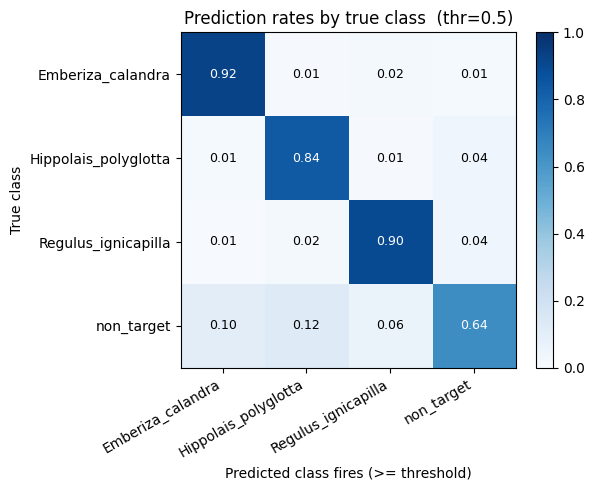

In [ ]:
rates = np.zeros((len(final_labels), len(final_labels)), dtype=np.float64)
for i in range(len(final_labels)):
    mask = y_true_bin[:, i] == 1
    if mask.any():
        rates[i] = y_pred_bin[mask].mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(rates, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(final_labels)))
ax.set_xticklabels(final_labels, rotation=30, ha="right")
ax.set_yticks(range(len(final_labels)))
ax.set_yticklabels(final_labels)
ax.set_xlabel("Predicted class fires (>= threshold)")
ax.set_ylabel("True class")
ax.set_title(f"Prediction rates by true class  (thr={THRESHOLD})")
for i in range(rates.shape[0]):
    for j in range(rates.shape[1]):
        ax.text(
            j, i, f"{rates[i, j]:.2f}",
            ha="center", va="center",
            color="white" if rates[i, j] > 0.5 else "black",
            fontsize=9,
        )
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## One-vs-rest ROC and AUC

For each class we compute ROC against "all the others" and report macro AUC.
This is the multiclass analogue of TinyChirp's binary ROC.

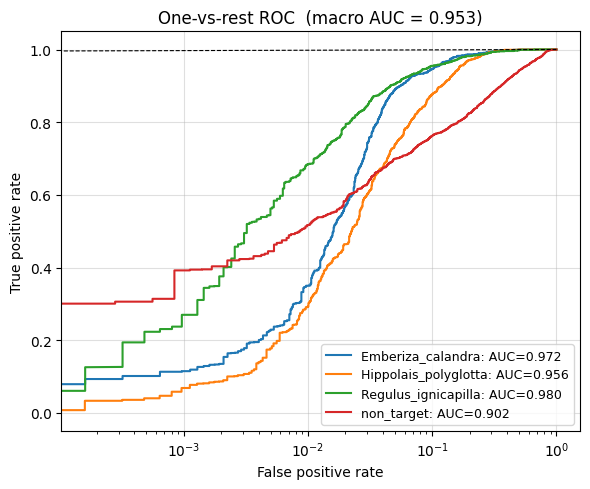

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

aucs: list[float] = []
fig, ax = plt.subplots(figsize=(6, 5))
for c, name in enumerate(final_labels):
    try:
        auc = roc_auc_score(y_true[:, c], y_pred[:, c])
        fpr, tpr, _ = roc_curve(y_true[:, c], y_pred[:, c])
    except ValueError as e:
        print(f"skipping {name}: {e}")
        continue
    aucs.append(auc)
    ax.plot(fpr, tpr, label=f"{name}: AUC={auc:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_xscale("log")
ax.set_title(f"One-vs-rest ROC  (macro AUC = {np.mean(aucs):.3f})")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## Save model and results record

In [ ]:
import json
from datetime import datetime, timezone

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
model.save(MODEL_PATH)
print(f"Saved model: {MODEL_PATH}")

record = {
    "collection": COLLECTION,
    "run_name": RUN_NAME,
    "build_model": BUILD_MODEL,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "epochs_trained": len(history.history["loss"]),
    "class_names": final_labels,
    "test_loss": test_loss,
    "subset_accuracy": subset_acc,
    "macro": {
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
        "f1": float(np.mean(f1s)),
        "f2": float(np.mean(f2s)),
        "auc_ovr": float(np.mean(aucs)) if aucs else None,
    },
    "per_class": {
        name: {
            "support": supports[i],
            "precision": float(precisions[i]),
            "recall": float(recalls[i]),
            "f1": float(f1s[i]),
            "f2": float(f2s[i]),
            "auc_ovr": float(aucs[i]) if i < len(aucs) else None,
        }
        for i, name in enumerate(final_labels)
    },
    "prediction_rates_by_true_class": rates.tolist(),
    "hyperparams": {
        "epochs": EPOCHS,
        "patience": PATIENCE,
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "threshold": THRESHOLD,
        "input_repr": input_repr,
    },
}
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
RESULTS_FILE.write_text(json.dumps(record, indent=2))
print(f"Wrote: {RESULTS_FILE}")

Saved model: /home/nathan/Documents/multi-chirp/models/task_s3_49_2_r50/cnn1d.keras
Wrote: /home/nathan/Documents/multi-chirp/results/task_s3_49_2_r50/cnn1d.json


In [ ]:
from building.scaling import cleanup_waveform_cache

# Wipe the waveform cache: reclaims a few GB and forces the next run to
# rebuild from disk so any dataset edits are picked up automatically.
cleanup_waveform_cache(COLLECTION)

[cleanup] removed /home/nathan/Documents/multi-chirp/.cache/task_s3_49_2_r50 (9,477.3 MB freed)
